# Guide Representation Across Technologies

Compare how guides are represented across the benchmark datasets:
1. **Cell counts per guide** — How many cells contain each guide? Are distributions similar?
2. **UMI distributions per guide** — Total, mean, and median UMI across cells for each guide
3. **Guide overlap** — Which guides are shared vs dataset-specific?
4. **Guide coverage uniformity** — Are some guides massively over/under-represented?

**Input:** `per_guide_capture.tsv` files from each dataset/run  
**Output:** Guide representation comparison plots and tables

In [15]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [16]:
# Project root
PROJECT_ROOT = Path("/cellar/users/aklie/data/datasets/tf_perturb_seq")

# Colors and ordering
sys.path.append(str(PROJECT_ROOT / "config"))
from loader import load_colors

dataset_colors = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_colors")
dataset_order = load_colors("technology-benchmark_WTC11_TF-Perturb-seq", "dataset_order")

# Short name helper
SUFFIX = '_WTC11-benchmark_TF-Perturb-seq'
def short_name(ds):
    return ds.replace(SUFFIX, '').replace('_', ' ')

short_names = [short_name(ds) for ds in dataset_order]
short_to_full = {short_name(ds): ds for ds in dataset_order}
color_by_short = {short_name(ds): dataset_colors[ds] for ds in dataset_order}

In [17]:
# Paths
RUN_LABEL = "cleanser_unified"  # or "sceptre_v11"
BASE_DIR = PROJECT_ROOT / "datasets" / "technology-benchmark_WTC11_TF-Perturb-seq"
QC_PATHS_FILE = BASE_DIR / "manifests" / f"{RUN_LABEL}_qc_paths.tsv"
OUTPUT_DIR = BASE_DIR / "results" / "cross_tech_comparison" / RUN_LABEL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Run: {RUN_LABEL}")
print(f"Manifest: {QC_PATHS_FILE}")
print(f"Output: {OUTPUT_DIR}")

Run: cleanser_unified
Manifest: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/manifests/cleanser_unified_qc_paths.tsv
Output: /cellar/users/aklie/data/datasets/tf_perturb_seq/datasets/technology-benchmark_WTC11_TF-Perturb-seq/results/cross_tech_comparison/cleanser_unified


In [18]:
# Load per-guide capture stats for all datasets
paths_df = pd.read_csv(QC_PATHS_FILE, sep="\t")

capture_list = []
for _, row in paths_df.iterrows():
    capture_file = Path(row['qc_dir']) / "guide" / "per_guide_capture.tsv"
    if capture_file.exists():
        df = pd.read_csv(capture_file, sep="\t")
        # Ensure dataset column is set
        if 'dataset' not in df.columns:
            df['dataset'] = row['dataset']
        capture_list.append(df)
        print(f"Loaded {row['dataset']}: {len(df)} guides, {df['total_cells'].iloc[0]:,} cells")
    else:
        print(f"WARNING: Missing {capture_file}")

capture_df = pd.concat(capture_list, ignore_index=True)
capture_df['short_name'] = capture_df['dataset'].apply(short_name)
capture_df['short_name'] = pd.Categorical(capture_df['short_name'], categories=short_names, ordered=True)

print(f"\nTotal: {len(capture_df):,} guide-dataset rows from {len(capture_list)} datasets")
capture_df.head()

Loaded Hon_WTC11-benchmark_TF-Perturb-seq: 416 guides, 73,458 cells
Loaded Huangfu_WTC11-benchmark_TF-Perturb-seq: 416 guides, 141,251 cells
Loaded Gersbach_WTC11-benchmark_TF-Perturb-seq_GEM-Xv3: 416 guides, 67,436 cells
Loaded Gersbach_WTC11-benchmark_TF-Perturb-seq_HTv2: 416 guides, 43,376 cells
Loaded Engreitz_WTC11-benchmark_TF-Perturb-seq: 416 guides, 467,119 cells

Total: 2,080 guide-dataset rows from 5 datasets


,guide_id,n_cells_detected,n_cells_assigned,frac_cells_detected,total_umi,mean_umi,median_umi,std_umi,max_umi,total_cells,dataset,short_name
0,CD81#strong,62399,NaN,0.849451,2146106.0,34.393276,2.0,194.774552,3091.0,73458,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
1,CD81#weak,61960,NaN,0.843475,2133658.0,34.436056,2.0,181.812574,3026.0,73458,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
2,CD151#strong,50335,NaN,0.685221,1290181.0,25.631886,2.0,149.189590,2302.0,73458,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
3,CD151#weak,63601,NaN,0.865814,2502029.0,39.339460,2.0,222.929149,4205.0,73458,Hon_WTC11-benchmark_TF-Perturb-seq,Hon
4,CD55#strong,44288,NaN,0.602902,969652.0,21.894238,1.0,114.062972,2452.0,73458,Hon_WTC11-benchmark_TF-Perturb-seq,Hon


---
## 1. Cell Counts per Guide

How many cells contain each guide? Compare the distributions across datasets.

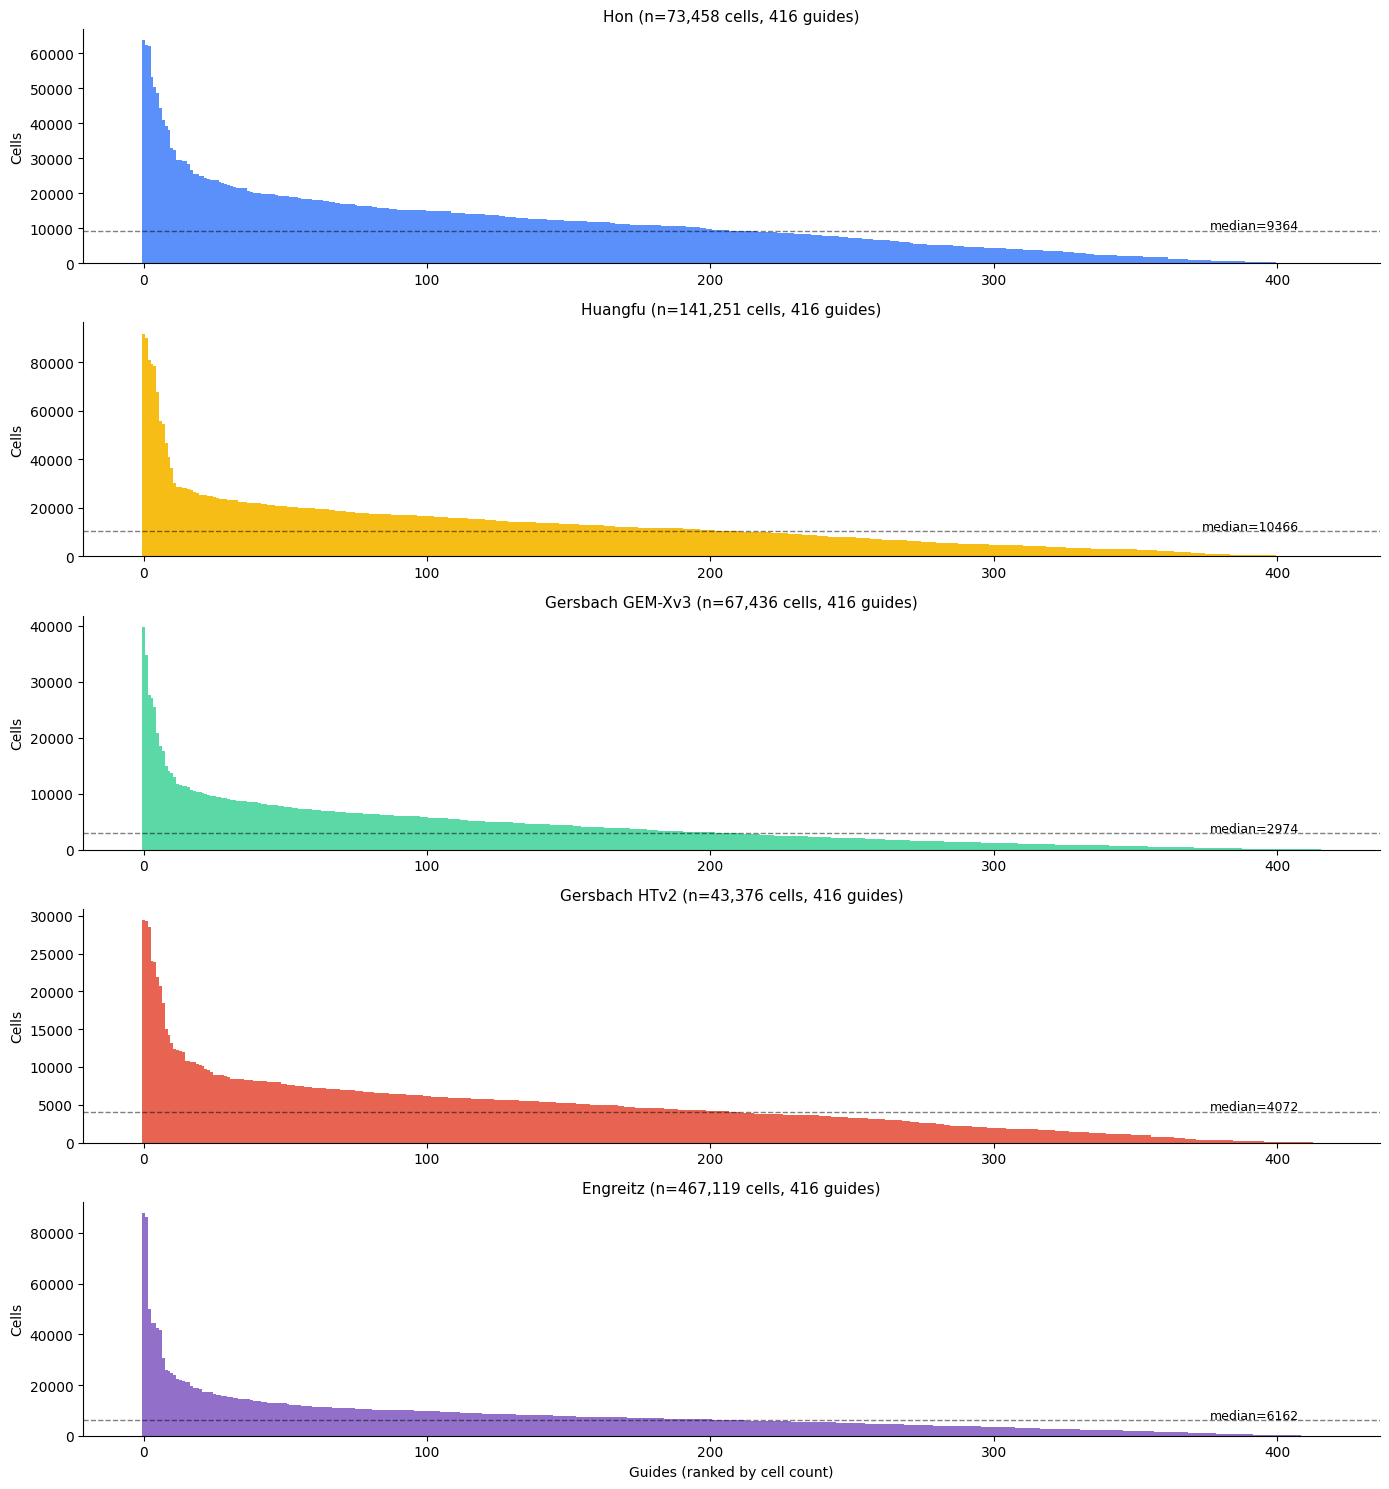

In [19]:
# Ranked bar chart of cells per guide (like the PSCs example)
fig, axes = plt.subplots(len(short_names), 1, figsize=(14, 3 * len(short_names)), sharex=False)

for i, sn in enumerate(short_names):
    ax = axes[i]
    ds_data = capture_df[capture_df['short_name'] == sn].sort_values('n_cells_detected', ascending=False).reset_index(drop=True)
    color = color_by_short[sn]
    ax.bar(range(len(ds_data)), ds_data['n_cells_detected'], color=color, edgecolor='none', width=1.0)
    ax.set_ylabel('Cells')
    ax.set_title(f'{sn} (n={ds_data["total_cells"].iloc[0]:,} cells, {len(ds_data)} guides)', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Annotate median
    med = ds_data['n_cells_detected'].median()
    ax.axhline(med, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(len(ds_data) * 0.98, med * 1.05, f'median={med:.0f}', ha='right', fontsize=9)

axes[-1].set_xlabel('Guides (ranked by cell count)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_cells_ranked_barplot.pdf", dpi=300, bbox_inches='tight')
plt.show()

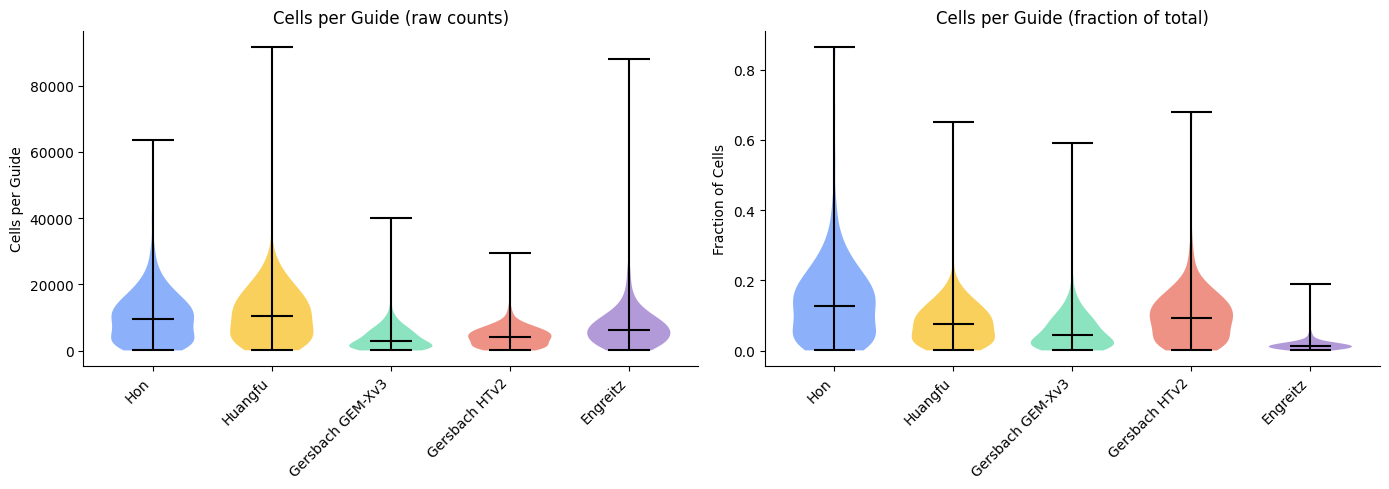

In [20]:
# Violin + box plot of cells per guide
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw cell counts
ax = axes[0]
for i, sn in enumerate(short_names):
    ds_data = capture_df[capture_df['short_name'] == sn]['n_cells_detected']
    vp = ax.violinplot([ds_data.values], positions=[i], showmedians=True, widths=0.7)
    for body in vp['bodies']:
        body.set_facecolor(color_by_short[sn])
        body.set_alpha(0.7)
    for part in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
        vp[part].set_color('black')
ax.set_xticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Cells per Guide')
ax.set_title('Cells per Guide (raw counts)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Fraction of cells
ax = axes[1]
for i, sn in enumerate(short_names):
    ds_data = capture_df[capture_df['short_name'] == sn]['frac_cells_detected']
    vp = ax.violinplot([ds_data.values], positions=[i], showmedians=True, widths=0.7)
    for body in vp['bodies']:
        body.set_facecolor(color_by_short[sn])
        body.set_alpha(0.7)
    for part in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
        vp[part].set_color('black')
ax.set_xticks(range(len(short_names)))
ax.set_xticklabels(short_names, rotation=45, ha='right')
ax.set_ylabel('Fraction of Cells')
ax.set_title('Cells per Guide (fraction of total)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_cells_violin.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# Summary table of cells per guide
cells_summary = capture_df.groupby('short_name')['n_cells_detected'].agg(
    ['median', 'mean', 'std', 'min', 'max']
).round(1)
cells_summary['total_cells'] = capture_df.groupby('short_name')['total_cells'].first()
cells_summary['n_guides'] = capture_df.groupby('short_name')['guide_id'].count()
cells_summary['median_frac'] = (cells_summary['median'] / cells_summary['total_cells']).round(4)
cells_summary

/tmp/ipykernel_111025/822257065.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_summary = capture_df.groupby('short_name')['n_cells_detected'].agg(
/tmp/ipykernel_111025/822257065.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_summary['total_cells'] = capture_df.groupby('short_name')['total_cells'].first()
/tmp/ipykernel_111025/822257065.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_summa

,median,mean,std,min,max,total_cells,n_guides,median_frac
short_name,,,,,,,,
Hon,9364.0,10703.0,9413.5,29,63601,73458,416,0.1275
Huangfu,10466.5,11976.7,11759.9,78,91780,141251,416,0.0741
Gersbach GEM-Xv3,2973.5,3971.7,4446.8,18,39873,67436,416,0.0441
Gersbach HTv2,4072.5,4525.1,4021.9,7,29463,43376,416,0.0939
Engreitz,6162.5,7573.4,8503.8,31,87910,467119,416,0.0132


---
## 2. UMI Distributions per Guide

Total, mean, and median UMI counts across cells for each guide.

In [ ]:
# Ranked bar chart of total UMI per guide
fig, axes = plt.subplots(len(short_names), 1, figsize=(14, 3 * len(short_names)), sharex=False)

for i, sn in enumerate(short_names):
    ax = axes[i]
    ds_data = capture_df[capture_df['short_name'] == sn].sort_values('total_umi', ascending=False).reset_index(drop=True)
    color = color_by_short[sn]
    ax.bar(range(len(ds_data)), ds_data['total_umi'], color=color, edgecolor='none', width=1.0)
    ax.set_ylabel('Total UMI')
    ax.set_title(f'{sn}', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    med = ds_data['total_umi'].median()
    ax.axhline(med, color='black', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(len(ds_data) * 0.98, med * 1.05, f'median={med:,.0f}', ha='right', fontsize=9)

axes[-1].set_xlabel('Guides (ranked by total UMI)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_total_umi_ranked_barplot.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Violin plots for mean and median UMI per guide
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ['total_umi', 'mean_umi', 'median_umi'],
    ['Total UMI per Guide', 'Mean UMI per Cell (per guide)', 'Median UMI per Cell (per guide)']
):
    for i, sn in enumerate(short_names):
        ds_data = capture_df[capture_df['short_name'] == sn][col].dropna()
        vp = ax.violinplot([ds_data.values], positions=[i], showmedians=True, widths=0.7)
        for body in vp['bodies']:
            body.set_facecolor(color_by_short[sn])
            body.set_alpha(0.7)
        for part in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
            vp[part].set_color('black')
    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_umi_violin.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Same but log-scaled for better comparison across datasets with different depths
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ['total_umi', 'mean_umi', 'median_umi'],
    ['Total UMI (log10)', 'Mean UMI (log10)', 'Median UMI (log10)']
):
    for i, sn in enumerate(short_names):
        ds_data = capture_df[capture_df['short_name'] == sn][col].dropna()
        ds_data = np.log10(ds_data[ds_data > 0])
        if len(ds_data) > 0:
            vp = ax.violinplot([ds_data.values], positions=[i], showmedians=True, widths=0.7)
            for body in vp['bodies']:
                body.set_facecolor(color_by_short[sn])
                body.set_alpha(0.7)
            for part in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
                vp[part].set_color('black')
    ax.set_xticks(range(len(short_names)))
    ax.set_xticklabels(short_names, rotation=45, ha='right')
    ax.set_ylabel('log10(UMI)')
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_umi_violin_log10.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Summary table of UMI stats
umi_summary = capture_df.groupby('short_name').agg(
    total_umi_median=('total_umi', 'median'),
    total_umi_mean=('total_umi', 'mean'),
    mean_umi_median=('mean_umi', 'median'),
    mean_umi_mean=('mean_umi', 'mean'),
    median_umi_median=('median_umi', 'median'),
    median_umi_mean=('median_umi', 'mean'),
).round(2)
umi_summary

---
## 3. Guide Overlap Across Datasets

Which guides are shared across all technologies, and which are dataset-specific?

In [ ]:
# Build detection matrix: which guides are detected (n_cells > 0) in which datasets
# Use a threshold: guide is "represented" if detected in at least N cells
MIN_CELLS = 1  # Minimum cells to count as detected

detected = capture_df[capture_df['n_cells_detected'] >= MIN_CELLS].copy()
detection_pivot = detected.pivot_table(
    index='guide_id', columns='short_name', values='n_cells_detected', aggfunc='first'
)
detection_binary = detection_pivot.notna().astype(int)

# All guide IDs across datasets
all_guides = capture_df['guide_id'].unique()
detection_binary = detection_binary.reindex(all_guides).fillna(0).astype(int)

print(f"Total unique guides: {len(all_guides)}")
print(f"\nGuides detected per dataset (>= {MIN_CELLS} cells):")
for sn in short_names:
    if sn in detection_binary.columns:
        print(f"  {sn}: {detection_binary[sn].sum()}")

In [ ]:
# Detection pattern analysis
cols = [sn for sn in short_names if sn in detection_binary.columns]
detection_binary['n_datasets'] = detection_binary[cols].sum(axis=1)
detection_binary['pattern'] = detection_binary[cols].apply(lambda x: '|'.join([cols[i] for i, v in enumerate(x) if v == 1]), axis=1)

# Histogram of number of datasets each guide is detected in
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of n_datasets
ax = axes[0]
counts = detection_binary['n_datasets'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black', linewidth=0.5)
for x, y in zip(counts.index, counts.values):
    ax.text(x, y + 1, str(y), ha='center', fontsize=10)
ax.set_xlabel('Number of Datasets')
ax.set_ylabel('Number of Guides')
ax.set_title('Guide Detection Across Datasets')
ax.set_xticks(range(0, len(cols) + 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: stacked bar showing shared vs unique
ax = axes[1]
categories = {
    f'All {len(cols)}': (detection_binary['n_datasets'] == len(cols)).sum(),
    f'{len(cols)-1}': (detection_binary['n_datasets'] == len(cols) - 1).sum(),
    'Dataset-specific (1)': (detection_binary['n_datasets'] == 1).sum(),
    'Not detected (0)': (detection_binary['n_datasets'] == 0).sum(),
}
if len(cols) > 3:
    categories['2-' + str(len(cols)-2)] = detection_binary['n_datasets'].between(2, len(cols)-2).sum()

cat_colors = ['#2ecc71', '#82e0aa', '#f39c12', '#e74c3c', '#85c1e9']
ax.barh(range(len(categories)), list(categories.values()), color=cat_colors[:len(categories)], edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(categories)))
ax.set_yticklabels(list(categories.keys()))
for i, v in enumerate(categories.values()):
    ax.text(v + 1, i, str(v), va='center', fontsize=10)
ax.set_xlabel('Number of Guides')
ax.set_title('Guide Sharing Categories')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_overlap_summary.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# UpSet-style: top detection patterns
pattern_counts = detection_binary['pattern'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(len(pattern_counts)), pattern_counts.values, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(pattern_counts)))
# Shorten labels
labels = [p if len(p) < 60 else p[:57] + '...' for p in pattern_counts.index]
ax.set_yticklabels(labels, fontsize=9)
for i, v in enumerate(pattern_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)
ax.set_xlabel('Number of Guides')
ax.set_title('Top Guide Detection Patterns')
ax.invert_yaxis()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_detection_patterns.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# List dataset-specific guides
for sn in short_names:
    if sn not in detection_binary.columns:
        continue
    other_cols = [c for c in cols if c != sn]
    mask = (detection_binary[sn] == 1) & (detection_binary[other_cols].sum(axis=1) == 0)
    specific = detection_binary[mask]
    print(f"\n{sn}-specific guides: {len(specific)}")
    if len(specific) > 0:
        # Show with their cell counts
        guide_ids = specific.index.tolist()
        full_ds = short_to_full[sn]
        sub = capture_df[(capture_df['guide_id'].isin(guide_ids)) & (capture_df['dataset'] == full_ds)]
        print(sub[['guide_id', 'n_cells_detected', 'total_umi', 'mean_umi']].sort_values('n_cells_detected', ascending=False).head(10).to_string(index=False))

---
## 4. Guide Coverage Uniformity

Are guides uniformly represented, or are some massively over/under-captured?

In [ ]:
# Coefficient of variation of cell counts within each dataset
# Measures how uniform the guide library representation is
cv_per_dataset = capture_df.groupby('short_name').agg(
    cells_cv=('n_cells_detected', lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan),
    umi_cv=('total_umi', lambda x: x.std() / x.mean() if x.mean() > 0 else np.nan),
    cells_gini=('n_cells_detected', lambda x: np.mean(np.abs(np.subtract.outer(x, x))) / (2 * x.mean()) if x.mean() > 0 else np.nan),
).round(3)

print("Uniformity metrics (lower = more uniform):")
cv_per_dataset

In [ ]:
# Lorenz curves for guide cell count distribution (uniformity visualization)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(
    axes,
    ['n_cells_detected', 'total_umi'],
    ['Cell Counts per Guide', 'Total UMI per Guide']
):
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect equality')
    for sn in short_names:
        ds_data = capture_df[capture_df['short_name'] == sn][col].sort_values().values
        if len(ds_data) == 0:
            continue
        cumulative = np.cumsum(ds_data) / ds_data.sum()
        x = np.linspace(0, 1, len(cumulative))
        ax.plot(x, cumulative, color=color_by_short[sn], linewidth=2, label=sn)
    ax.set_xlabel('Fraction of Guides (ranked)')
    ax.set_ylabel('Cumulative Fraction')
    ax.set_title(f'Lorenz Curve: {title}')
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_uniformity_lorenz.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Cross-technology correlation: are the same guides over/under-represented?
# Pivot to guides x datasets for cell counts
cells_matrix = capture_df.pivot(index='guide_id', columns='short_name', values='n_cells_detected')
cells_matrix = cells_matrix[[sn for sn in short_names if sn in cells_matrix.columns]]

# Pairwise scatter matrix
ds_cols = list(cells_matrix.columns)
n = len(ds_cols)
fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i < j:
            ax.axis('off')
        elif i == j:
            vals = cells_matrix[ds_cols[i]].dropna()
            ax.hist(vals, bins=30, color=color_by_short[ds_cols[i]], alpha=0.7, edgecolor='black', linewidth=0.3)
            ax.set_title(ds_cols[i], fontsize=10)
        else:
            x = cells_matrix[ds_cols[j]]
            y = cells_matrix[ds_cols[i]]
            mask = x.notna() & y.notna()
            if mask.sum() > 2:
                r, p = stats.pearsonr(x[mask], y[mask])
                ax.scatter(x[mask], y[mask], alpha=0.3, s=10, c='black')
                max_val = max(x[mask].max(), y[mask].max())
                ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5)
                ax.text(0.05, 0.95, f'r={r:.2f}', transform=ax.transAxes, va='top', fontsize=9)
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('Cross-Technology Correlation: Cells per Guide', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_cells_correlation_matrix.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Same for mean UMI per guide
umi_matrix = capture_df.pivot(index='guide_id', columns='short_name', values='mean_umi')
umi_matrix = umi_matrix[[sn for sn in short_names if sn in umi_matrix.columns]]

ds_cols_umi = list(umi_matrix.columns)
n = len(ds_cols_umi)
fig, axes = plt.subplots(n, n, figsize=(3 * n, 3 * n))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if i < j:
            ax.axis('off')
        elif i == j:
            vals = umi_matrix[ds_cols_umi[i]].dropna()
            ax.hist(vals, bins=30, color=color_by_short[ds_cols_umi[i]], alpha=0.7, edgecolor='black', linewidth=0.3)
            ax.set_title(ds_cols_umi[i], fontsize=10)
        else:
            x = umi_matrix[ds_cols_umi[j]]
            y = umi_matrix[ds_cols_umi[i]]
            mask = x.notna() & y.notna()
            if mask.sum() > 2:
                r, p = stats.pearsonr(x[mask], y[mask])
                ax.scatter(x[mask], y[mask], alpha=0.3, s=10, c='black')
                max_val = max(x[mask].max(), y[mask].max())
                ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5)
                ax.text(0.05, 0.95, f'r={r:.2f}', transform=ax.transAxes, va='top', fontsize=9)
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

fig.suptitle('Cross-Technology Correlation: Mean UMI per Guide', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_umi_correlation_matrix.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Identify outlier guides: very high or very low representation across technologies
# Use the fraction of cells to normalize across dataset sizes
frac_matrix = capture_df.pivot(index='guide_id', columns='short_name', values='frac_cells_detected')
frac_matrix = frac_matrix[[sn for sn in short_names if sn in frac_matrix.columns]]

frac_cols = list(frac_matrix.columns)
frac_matrix['mean_frac'] = frac_matrix[frac_cols].mean(axis=1)
frac_matrix['std_frac'] = frac_matrix[frac_cols].std(axis=1)
frac_matrix['cv'] = frac_matrix['std_frac'] / frac_matrix['mean_frac']

# Top 20 most variable guides (high CV)
most_variable = frac_matrix.nlargest(20, 'cv')

fig, ax = plt.subplots(figsize=(8, 8))
plot_data = most_variable[frac_cols]
plot_data.index = [f"{idx[:35]}..." if len(idx) > 35 else idx for idx in plot_data.index]
sns.heatmap(plot_data, cmap='YlOrRd', ax=ax, annot=True, fmt='.3f',
            cbar_kws={'label': 'Fraction of Cells'})
ax.set_title('Top 20 Most Variable Guides Across Technologies\n(by CV of cell detection fraction)')
ax.set_xlabel('Dataset')
ax.set_ylabel('Guide ID')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_most_variable_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Top and bottom guides by mean capture across all datasets
frac_matrix_sorted = frac_matrix.sort_values('mean_frac')
bottom_10 = frac_matrix_sorted.head(10)
top_10 = frac_matrix_sorted.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top captured
ax = axes[0]
plot_data = top_10[frac_cols].iloc[::-1]
plot_data.index = [f"{idx[:30]}..." if len(idx) > 30 else idx for idx in plot_data.index]
sns.heatmap(plot_data, cmap='YlOrRd', ax=ax, annot=True, fmt='.3f',
            cbar_kws={'label': 'Fraction of Cells'})
ax.set_title('Top 10 Most-Captured Guides')

# Bottom captured
ax = axes[1]
plot_data = bottom_10[frac_cols]
plot_data.index = [f"{idx[:30]}..." if len(idx) > 30 else idx for idx in plot_data.index]
sns.heatmap(plot_data, cmap='YlOrRd', ax=ax, annot=True, fmt='.3f',
            cbar_kws={'label': 'Fraction of Cells'})
ax.set_title('Bottom 10 Least-Captured Guides')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "guide_top_bottom_captured.pdf", dpi=300, bbox_inches='tight')
plt.show()

---
## Save Outputs

In [ ]:
# Save combined per-guide capture data
capture_df.to_csv(OUTPUT_DIR / "combined_per_guide_capture.tsv", sep="\t", index=False)
print(f"Saved: {OUTPUT_DIR / 'combined_per_guide_capture.tsv'}")

# Save cell detection fraction matrix
frac_matrix.to_csv(OUTPUT_DIR / "guide_frac_cells_matrix.tsv", sep="\t")
print(f"Saved: {OUTPUT_DIR / 'guide_frac_cells_matrix.tsv'}")

# Save detection binary matrix
detection_binary.to_csv(OUTPUT_DIR / "guide_detection_binary.tsv", sep="\t")
print(f"Saved: {OUTPUT_DIR / 'guide_detection_binary.tsv'}")

# Save summary tables
cells_summary.to_csv(OUTPUT_DIR / "guide_cells_summary.tsv", sep="\t")
umi_summary.to_csv(OUTPUT_DIR / "guide_umi_summary.tsv", sep="\t")
print(f"Saved summary tables")

---
# DONE!